In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORDERBOOK_FILE="/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/data/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"

columns=[]
for level in range(1,11):
    columns.append(f"ask_price_{level}")
    columns.append(f"ask_size_{level}")
    columns.append(f"bid_price_{level}")
    columns.append(f"bid_size_{level}")

print(f"Total Columns: {len(columns)}")
print(f"First few: {columns[:4]}")


Total Columns: 40
First few: ['ask_price_1', 'ask_size_1', 'bid_price_1', 'bid_size_1']


In [58]:
df= pd.read_csv(ORDERBOOK_FILE, names=columns)
print(f"Shape: {df.shape}")
df.head()


Shape: (400391, 40)


,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,5859400,200,5853300,18,5859800,200,5853000,150,5861000,200,...,5845300,300,5876500,1160,5843800,200,5879000,500,5842700,300
1,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5846500,300,5876500,1160,5845300,300,5879000,500,5843800,200
2,5859400,200,5853300,18,5859800,200,5853200,18,5861000,200,...,5849300,300,5876500,1160,5846500,300,5879000,500,5845300,300
3,5859100,18,5853300,18,5859400,200,5853200,18,5859800,200,...,5849300,300,5873900,100,5846500,300,5876500,1160,5845300,300
4,5859100,18,5853300,18,5859200,18,5853200,18,5859400,200,...,5849300,300,5871000,10,5846500,300,5873900,100,5845300,300


In [59]:
price_columns=[col for col in df.columns if "price" in col]
print(f"Price columns: {price_columns}")
df[price_columns] = df[price_columns] / 10000
df.head()

Price columns: ['ask_price_1', 'bid_price_1', 'ask_price_2', 'bid_price_2', 'ask_price_3', 'bid_price_3', 'ask_price_4', 'bid_price_4', 'ask_price_5', 'bid_price_5', 'ask_price_6', 'bid_price_6', 'ask_price_7', 'bid_price_7', 'ask_price_8', 'bid_price_8', 'ask_price_9', 'bid_price_9', 'ask_price_10', 'bid_price_10']


,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,...,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,...,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,...,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300


Read the [col for col in columns if "price" in col] line carefully. It's called a list comprehension — a compact way to filter a list. It means: "build a list of col for each col in columns, but only keep ones where "price" appears in the name." You'll use this pattern constantly.
After running, the prices should now look like 142.10, 142.08 — readable dollar amounts.


In [60]:
df.shape

(400391, 40)

In [61]:
df.head(10)

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
0,585.94,200,585.33,18,585.98,200,585.30,150,586.10,200,...,584.53,300,587.65,1160,584.38,200,587.90,500,584.27,300
1,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.65,300,587.65,1160,584.53,300,587.90,500,584.38,200
2,585.94,200,585.33,18,585.98,200,585.32,18,586.10,200,...,584.93,300,587.65,1160,584.65,300,587.90,500,584.53,300
3,585.91,18,585.33,18,585.94,200,585.32,18,585.98,200,...,584.93,300,587.39,100,584.65,300,587.65,1160,584.53,300
4,585.91,18,585.33,18,585.92,18,585.32,18,585.94,200,...,584.93,300,587.10,10,584.65,300,587.39,100,584.53,300
5,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,...,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
6,585.91,18,585.33,18,585.92,18,585.32,18,585.93,18,...,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
7,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,...,584.97,5,587.00,100,584.93,300,587.10,10,584.65,300
8,585.91,18,585.33,18,585.92,18,585.32,18,585.93,118,...,584.93,300,587.00,100,584.65,300,587.10,10,584.53,300
9,585.91,18,585.33,18,585.92,18,585.30,150,585.93,118,...,584.65,300,587.00,100,584.53,300,587.10,10,584.38,200


In [62]:
df.tail(10)

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
400381,577.67,462,577.60,114,577.68,200,577.55,11,577.69,160,...,577.49,110,577.77,100,577.48,200,577.78,200,577.46,100
400382,577.67,462,577.60,114,577.68,200,577.54,410,577.69,160,...,577.48,200,577.77,100,577.46,100,577.78,200,577.45,200
400383,577.67,300,577.60,114,577.68,200,577.54,410,577.69,160,...,577.48,200,577.77,100,577.46,100,577.78,200,577.45,200
400384,577.67,300,577.60,11,577.68,200,577.54,410,577.69,160,...,577.48,200,577.77,100,577.46,100,577.78,200,577.45,200
400385,577.67,300,577.54,410,577.68,200,577.53,1400,577.69,160,...,577.46,100,577.77,100,577.45,200,577.78,200,577.43,100
400386,577.61,48,577.54,410,577.67,300,577.53,1400,577.68,200,...,577.46,100,577.76,100,577.45,200,577.77,100,577.43,100
400387,577.61,48,577.54,410,577.67,300,577.53,1400,577.68,200,...,577.46,100,577.75,600,577.45,200,577.76,100,577.43,100
400388,577.61,48,577.54,410,577.67,300,577.53,1400,577.68,200,...,577.46,100,577.75,600,577.45,200,577.76,100,577.43,100
400389,577.67,300,577.54,410,577.68,200,577.53,1400,577.69,160,...,577.46,100,577.76,100,577.45,200,577.78,200,577.43,100
400390,577.67,300,577.54,410,577.68,200,577.53,1400,577.69,160,...,577.46,100,577.76,100,577.45,200,577.78,200,577.43,100


In [63]:
df.describe()

,ask_price_1,ask_size_1,bid_price_1,bid_size_1,ask_price_2,ask_size_2,bid_price_2,bid_size_2,ask_price_3,ask_size_3,...,bid_price_8,bid_size_8,ask_price_9,ask_size_9,bid_price_9,bid_size_9,ask_price_10,ask_size_10,bid_price_10,bid_size_10
count,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,...,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000,400391.000000
mean,583.229593,140.123622,583.076104,184.085441,583.258557,130.478887,583.041865,181.764430,583.284200,135.760934,...,582.881040,183.431236,583.428788,163.330627,582.857550,190.018402,583.453199,171.883302,582.834012,202.263947
std,2.850828,288.579234,2.819534,532.130359,2.855151,283.049948,2.812867,445.093067,2.859128,299.097387,...,2.780863,507.245160,2.882942,291.077967,2.776171,469.600016,2.887408,325.069497,2.771341,545.261433
min,577.500000,1.000000,577.450000,1.000000,577.520000,1.000000,577.420000,1.000000,577.530000,1.000000,...,577.360000,1.000000,577.610000,1.000000,577.340000,1.000000,577.620000,1.000000,577.330000,1.000000
25%,581.300000,33.000000,581.180000,94.000000,581.320000,18.000000,581.150000,100.000000,581.340000,21.000000,...,581.010000,33.000000,581.470000,50.000000,581.000000,40.000000,581.490000,60.000000,580.980000,50.000000
50%,583.310000,100.000000,583.170000,100.000000,583.340000,100.000000,583.130000,100.000000,583.360000,100.000000,...,583.000000,100.000000,583.500000,100.000000,582.970000,100.000000,583.510000,100.000000,582.950000,100.000000
75%,585.770000,140.000000,585.560000,200.000000,585.800000,119.000000,585.510000,200.000000,585.830000,123.000000,...,585.320000,164.000000,586.000000,128.000000,585.290000,169.000000,586.020000,150.000000,585.250000,200.000000
max,588.220000,15041.000000,588.150000,22244.000000,588.230000,15041.000000,588.120000,22244.000000,588.240000,15041.000000,...,587.910000,22444.000000,588.340000,7266.000000,587.890000,22244.000000,588.350000,7266.000000,587.880000,22244.000000


In [64]:
df["mid_price"] = (df["ask_price_1"]+df["bid_price_1"])/2
df["spread"]=(df["ask_price_1"]-df["bid_price_1"])

In [65]:
print(f"Mid-price range: {df['mid_price'].min():.2f} to {df['mid_price'].max():.2f}")
print(f"Mean spread: {df['spread'].mean():.4f}")
print(f"Median spread: {df['spread'].median():.4f}")

Mid-price range: 577.48 to 588.18
Mean spread: 0.1535
Median spread: 0.1500


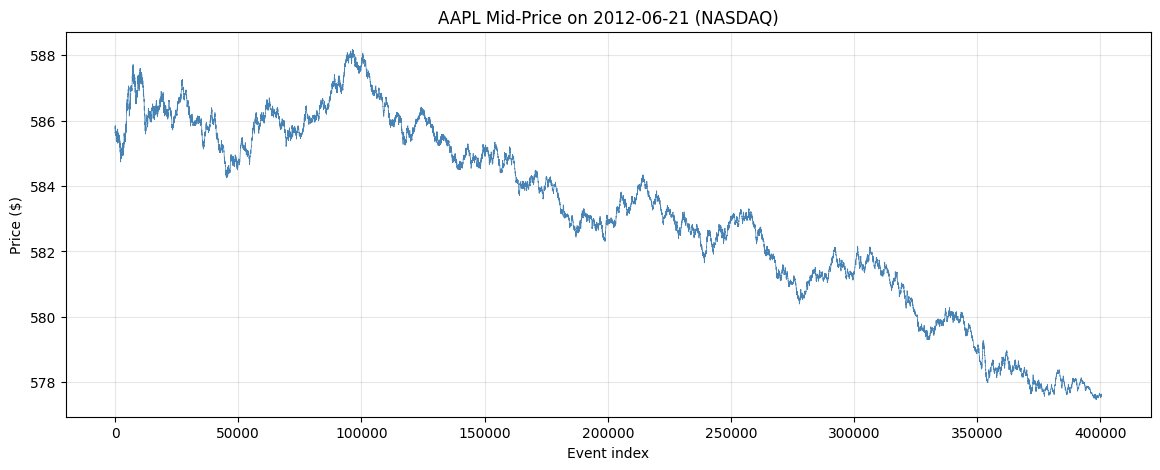

In [66]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["mid_price"], linewidth=0.5, color="steelblue")
plt.title("AAPL Mid-Price on 2012-06-21 (NASDAQ)")
plt.xlabel("Event index")
plt.ylabel("Price ($)")
plt.grid(True, alpha=0.3)
plt.savefig("/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/outputs/01_midprice.png", dpi=150, bbox_inches="tight")
plt.show()

In [67]:
MESSAGE_FILE = "/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/data/AAPL_2012-06-21_34200000_57600000_message_10.csv"
message_columns = [ "time_sec", "event_type", "order_id", "size", "price", "distribution"]
messages = pd.read_csv(MESSAGE_FILE,header=None,names=message_columns)
messages.head()
print(f"Message shape: {messages.shape}")
print(f"First time: {messages['time_sec'].iloc[0]}")
print(f"Last time: {messages['time_sec'].iloc[-1]}")


Message shape: (400391, 6)
First time: 34200.004241176
Last time: 57599.913117637


In [68]:
df["time_sec"] = messages["time_sec"].values   # .values strips the index
df["time_hour"] = df["time_sec"] / 3600         # convert to hours past midnight

print(df[["time_sec", "time_hour", "mid_price", "spread"]].head())

       time_sec  time_hour  mid_price  spread
0  34200.004241   9.500001    585.635    0.61
1  34200.004261   9.500001    585.635    0.61
2  34200.004447   9.500001    585.635    0.61
3  34200.025552   9.500007    585.620    0.58
4  34200.025580   9.500007    585.620    0.58


/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction

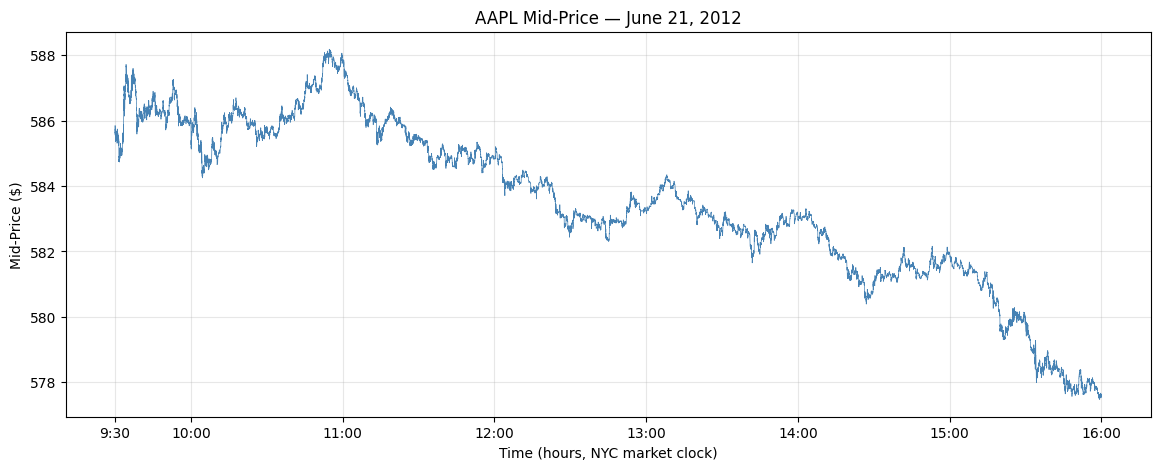

In [69]:
plt.figure(figsize=(14, 5))
plt.plot(df["time_hour"], df["mid_price"], linewidth=0.5, color="steelblue")
plt.title("AAPL Mid-Price — June 21, 2012")
plt.xlabel("Time (hours, NYC market clock)")
plt.ylabel("Mid-Price ($)")
plt.grid(True, alpha=0.3)
plt.xticks([9.5, 10, 11, 12, 13, 14, 15, 16], 
           ["9:30", "10:00", "11:00", "12:00", "13:00", "14:00", "15:00", "16:00"])
plt.savefig("/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/outputs/02_midprice_clocktime.png", dpi=150, bbox_inches="tight")
plt.show()

The plt.xticks(...) part replaces the boring decimals with clock times. Much more readable. This is a small detail that makes recruiters say "this person cares about presentation."

The bid-ask spread is the cost of trading. Its distribution tells you a huge amount about the stock.


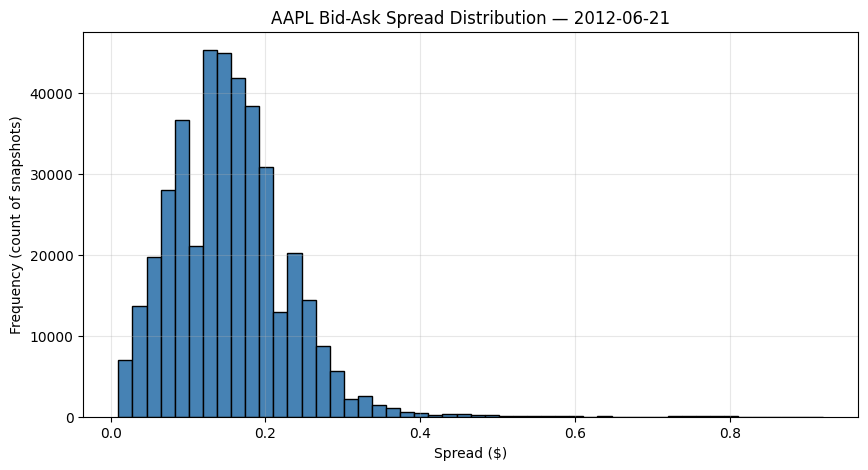

Min spread: $0.0100
Median spread: $0.1500
Max spread: $0.9200
Most common spread: $0.1300


In [70]:
# Plot 2: Bid-Ask Spread Distribution (Histogram)
plt.figure(figsize=(10, 5))
plt.hist(df["spread"], bins=50, color="steelblue", edgecolor="black")
plt.title("AAPL Bid-Ask Spread Distribution — 2012-06-21")
plt.xlabel("Spread ($)")
plt.ylabel("Frequency (count of snapshots)")
plt.grid(True, alpha=0.3)
plt.savefig("/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/outputs/03_spread_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Print some stats too
print(f"Min spread: ${df['spread'].min():.4f}")
print(f"Median spread: ${df['spread'].median():.4f}")
print(f"Max spread: ${df['spread'].max():.4f}")
print(f"Most common spread: ${df['spread'].mode().iloc[0]:.4f}")


In [71]:
# Top-of-book OFI (level 1 only)
df["ofi_top"] = (df["bid_size_1"] - df["ask_size_1"]) / (df["bid_size_1"] + df["ask_size_1"])

print(df["ofi_top"].describe())

count    400391.000000
mean          0.069742
std           0.569703
min          -0.999375
25%          -0.333333
50%           0.000000
75%           0.587302
max           0.999513
Name: ofi_top, dtype: float64


In [72]:
bid_size_columns = [f"bid_size_{level}" for level in range (1,11)]
ask_size_columns = [f"ask_size_{level}" for level in range (1,11)]
# Sum across columns (axis=1 means "sum across columns, row by row")
df["total_bid_size"]= df[bid_size_columns].sum(axis=1)
df["total_ask_size"]= df[ask_size_columns].sum(axis=1)

df["ofi_deep"] = (df["total_bid_size"] - df["total_ask_size"]) / (df["total_bid_size"] + df["total_ask_size"])

print(df[["ofi_top", "ofi_deep"]].head())
print()
print(df[["ofi_top", "ofi_deep"]].describe())

    ofi_top  ofi_deep
0 -0.834862 -0.256965
1 -0.834862 -0.341260
2 -0.834862 -0.401939
3  0.000000 -0.320531
4  0.000000  0.002918

             ofi_top       ofi_deep
count  400391.000000  400391.000000
mean        0.069742       0.073022
std         0.569703       0.347820
min        -0.999375      -0.921767
25%        -0.333333      -0.164200
50%         0.000000       0.084043
75%         0.587302       0.321769
max         0.999513       0.955301


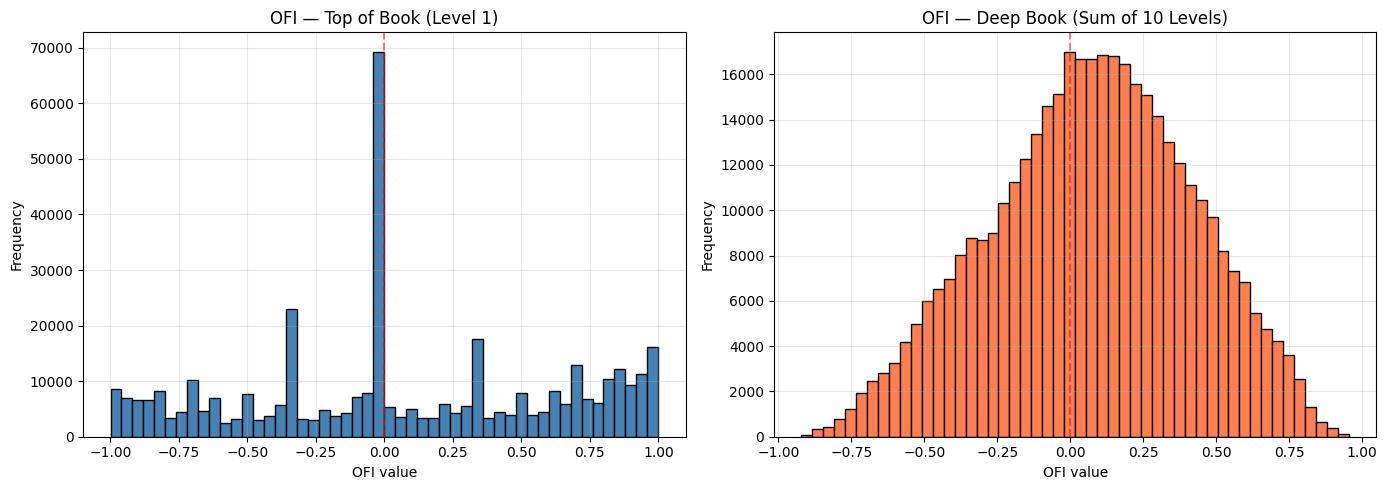

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["ofi_top"], bins=50, color="steelblue", edgecolor="black")
axes[0].set_title("OFI — Top of Book (Level 1)")
axes[0].set_xlabel("OFI value")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, alpha=0.3)
axes[0].axvline(0, color="red", linestyle="--", alpha=0.5)   # vertical line at 0

axes[1].hist(df["ofi_deep"], bins=50, color="coral", edgecolor="black")
axes[1].set_title("OFI — Deep Book (Sum of 10 Levels)")
axes[1].set_xlabel("OFI value")
axes[1].set_ylabel("Frequency")
axes[1].grid(True, alpha=0.3)
axes[1].axvline(0, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("../outputs/04_ofi_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [74]:
# Take every 80th row for a clean plot (400K / 80 ≈ 5000)
df_sub = df.iloc[::80].copy()
print(f"Subsampled shape: {df_sub.shape}")
# df.iloc[::80] = "take every 80th row." The ::80 is a slicing trick.

Subsampled shape: (5005, 48)


In [75]:
# Build a 20-row × N-column matrix
ask_size_matrix = df_sub[[f"ask_size_{i}" for i in range(10, 0, -1)]].values.T  # 10 ask levels, deepest at top
bid_size_matrix = df_sub[[f"bid_size_{i}" for i in range(1, 11)]].values.T    # 10 bid levels, top first

# Stack them: asks on top, bids on bottom
depth_matrix = np.vstack([ask_size_matrix, bid_size_matrix])
print(f"Depth matrix shape: {depth_matrix.shape}")  # should be (20, ~5000)

Depth matrix shape: (20, 5005)


Shape: (20, 5005)
Min: 1
Max: 22244
Median: 100.0


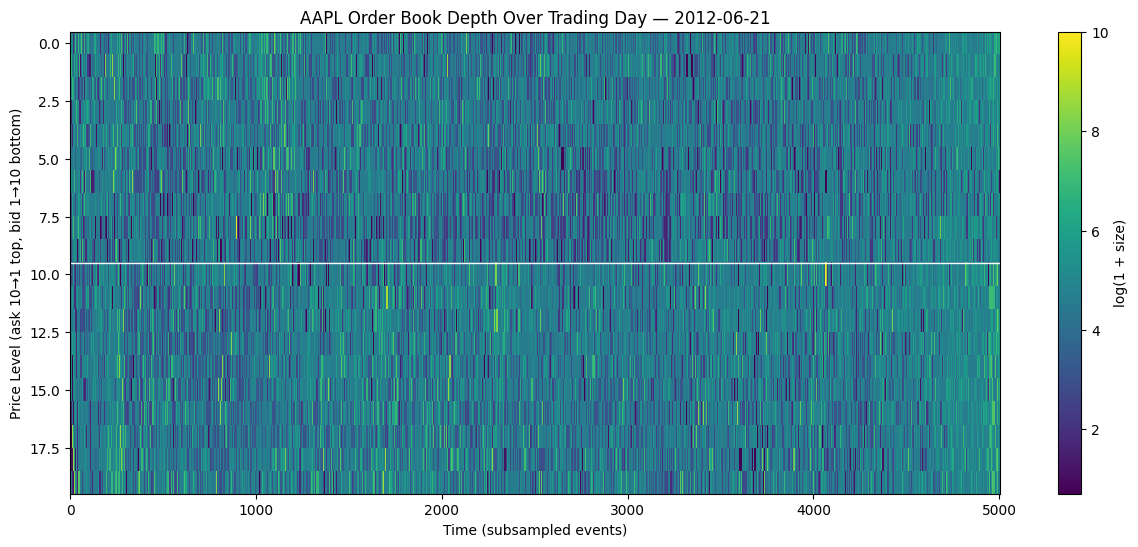

In [82]:
import numpy as np

# Build the depth matrix (same as before)
ask_size_matrix = df_sub[[f"ask_size_{i}" for i in range(10, 0, -1)]].values.T
bid_size_matrix = df_sub[[f"bid_size_{i}" for i in range(1, 11)]].values.T
depth_matrix = np.vstack([ask_size_matrix, bid_size_matrix])

# Diagnostic — confirm matrix has variation
print(f"Shape: {depth_matrix.shape}")
print(f"Min: {depth_matrix.min()}")
print(f"Max: {depth_matrix.max()}")
print(f"Median: {np.median(depth_matrix)}")

# Plot with log scale to handle wide value range
plt.figure(figsize=(15, 6))
plt.imshow(np.log1p(depth_matrix), aspect="auto", cmap="viridis", interpolation="nearest")
plt.colorbar(label="log(1 + size)")
plt.title("AAPL Order Book Depth Over Trading Day — 2012-06-21")
plt.xlabel("Time (subsampled events)")
plt.ylabel("Price Level (ask 10→1 top, bid 1→10 bottom)")
plt.axhline(y=9.5, color="white", linewidth=1)
plt.savefig("/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/outputs/05_depth_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

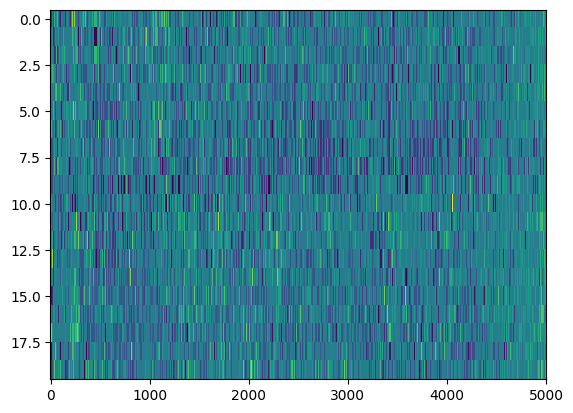

In [77]:
# Use log scale for color since sizes vary by orders of magnitude
plt.imshow(np.log1p(depth_matrix), aspect="auto", cmap="viridis", interpolation="nearest")

In [78]:
print(f"Depth matrix shape: {depth_matrix.shape}")     # should be (20, ~5000)
print(f"Depth matrix min: {depth_matrix.min()}")        # should be 0
print(f"Depth matrix max: {depth_matrix.max()}")        # probably tens of thousands
print(f"Depth matrix median: {np.median(depth_matrix)}")

Depth matrix shape: (20, 5005)
Depth matrix min: 1
Depth matrix max: 22244
Depth matrix median: 100.0


/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction

In [79]:
pip install fastparquet

Note: you may need to restart the kernel to use updated packages.


In [80]:
# Save only the columns we need for the next stage
columns_to_save = [
    "time_sec", "time_hour",
    "ask_price_1", "ask_size_1", "bid_price_1", "bid_size_1",
    "mid_price", "spread",
    "ofi_top", "ofi_deep",
    "total_bid_size", "total_ask_size",
] + [f"ask_price_{i}" for i in range(2, 11)] \
  + [f"ask_size_{i}" for i in range(2, 11)] \
  + [f"bid_price_{i}" for i in range(2, 11)] \
  + [f"bid_size_{i}" for i in range(2, 11)]

df_save = df[columns_to_save]
df_save.to_parquet("/Users/anirudhgoyal/Desktop/Projects/lob-midprice-prediction/data/aapl_stage2.parquet", engine='fastparquet')
print(f"Saved {df_save.shape[0]} rows to parquet")

Saved 400391 rows to parquet


In [81]:
print(df["ask_price_1"].head())
print(df["bid_price_1"].head())
print(df["mid_price"].head())

0    585.94
1    585.94
2    585.94
3    585.91
4    585.91
Name: ask_price_1, dtype: float64
0    585.33
1    585.33
2    585.33
3    585.33
4    585.33
Name: bid_price_1, dtype: float64
0    585.635
1    585.635
2    585.635
3    585.620
4    585.620
Name: mid_price, dtype: float64
